# Importing libraries

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox

# Plotting
import matplotlib.pyplot as plt


# Paths based on structure
PROJECT_DIR = Path("..")
REF_DIR = PROJECT_DIR / "data" / "reference"

REF_DIR.mkdir(parents=True, exist_ok=True)

# GBFS and GeoDataFrame generation

In [9]:
# GBFS active stations parquet from 01_cdmx_GBFSstation_map.ipynb
stations_ref = pd.read_parquet("../data/reference/stations_gbfs_current.parquet")


In [ ]:
# Generate working df for marge
stations_gdf = gpd.GeoDataFrame(
    stations_ref,
    geometry=gpd.points_from_xy(stations_ref['lon'], stations_ref['lat']),
    crs='EPSG:4326'
)

# metros is already a GeoDataFrame
metros = ox.features_from_place('Mexico City, Mexico', tags={'station': 'subway'})

/Users/francobastida/miniconda3/envs/ecobici/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/francobastida/miniconda3/envs/ecobici/lib/python3.11/site-packages/shapely/set_operations.py:451: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)


In [ ]:
# Multimodality feature: for each GBFS station, find distance to nearest metros
stations_gdf['distance_to_metro'] = stations_gdf.geometry.apply(
    lambda point: metros.geometry.distance(point).min()
)

stations_gdf['nearest_metro_name'] = stations_gdf.geometry.apply(
    lambda point: metros.loc[metros.geometry.distance(point).idxmin(), 'name']
)

/var/folders/z3/_4r433cx6vb0c7n920xjj_g80000gn/T/ipykernel_40760/2941590251.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lambda point: metros.geometry.distance(point).min()
/var/folders/z3/_4r433cx6vb0c7n920xjj_g80000gn/T/ipykernel_40760/2941590251.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lambda point: metros.loc[metros.geometry.distance(point).idxmin(), 'name']


In [ ]:
# Column check 
print(stations_gdf.columns.tolist())
print(stations_ref.columns.tolist())

['station_id', 'name', 'short_name', 'lat', 'lon', 'capacity', 'geometry', 'distance_to_metro', 'nearest_metro_name']
['station_id', 'name', 'short_name', 'lat', 'lon', 'capacity']


In [15]:
# New data frame
output_df = stations_gdf[[
    'station_id', 'name', 'short_name', 'lat', 'lon', 'capacity', 'distance_to_metro', 'nearest_metro_name'
]].copy()

In [16]:
output_df

,station_id,name,short_name,lat,lon,capacity,distance_to_metro,nearest_metro_name
0,1,CE-710 Molino del Rey - Glorieta de la Lealtad,710,19.416795,-99.192508,39,0.005168,Constituyentes
1,5,CE-407 Prolongación Xochicalco-General Emilia...,407,19.367266,-99.158656,19,0.003369,Parque de los Venados
2,6,CE-428 Prolongación Uxmal-Av. Popocatépetl (E...,428,19.363404,-99.160395,27,0.007407,Parque de los Venados
3,7,CE-427 Avenida México-Coyoacán-Av. Popocatépet...,427,19.364906,-99.162987,19,0.006044,Zapata
4,8,CE-443 Bruno Traven-Golondrinas,443,19.359583,-99.162085,31,0.010746,Eje Central
...,...,...,...,...,...,...,...,...
672,697,CE-511 Palestina - Egipto,511,19.463941,-99.182280,27,0.006762,Cuitláhuac
673,698,CE-682 Manuel M. Ponce - Fernando M. Villalpando,682,19.353534,-99.189548,23,0.008024,Barranca del Muerto
674,699,CE-681 Guty Cárdenas - Ricardo Castro,681,19.355844,-99.189141,19,0.005710,Barranca del Muerto
675,700,CE-711 Molino del Rey - Av. Constituyentes,711,19.414108,-99.191983,39,0.002433,Constituyentes


- Output is in Euclidean distance, meaning decimal degrees
- For interpretability, they would need to be converted or at least put into context for the distribution

# Summary statistics and analysis of distribution

Distance to Metro Statistics (decimal degrees):
count    677.000000
mean       0.005809
std        0.003888
min        0.000000
25%        0.002965
50%        0.004946
75%        0.008049
max        0.020690
Name: distance_to_metro, dtype: float64

Distance to Metro Statistics (meters):
count     677.000000
mean      644.784360
std       431.580569
min         0.000000
25%       329.156226
50%       549.006337
75%       893.394543
max      2296.550431
Name: distance_to_metro_m, dtype: float64


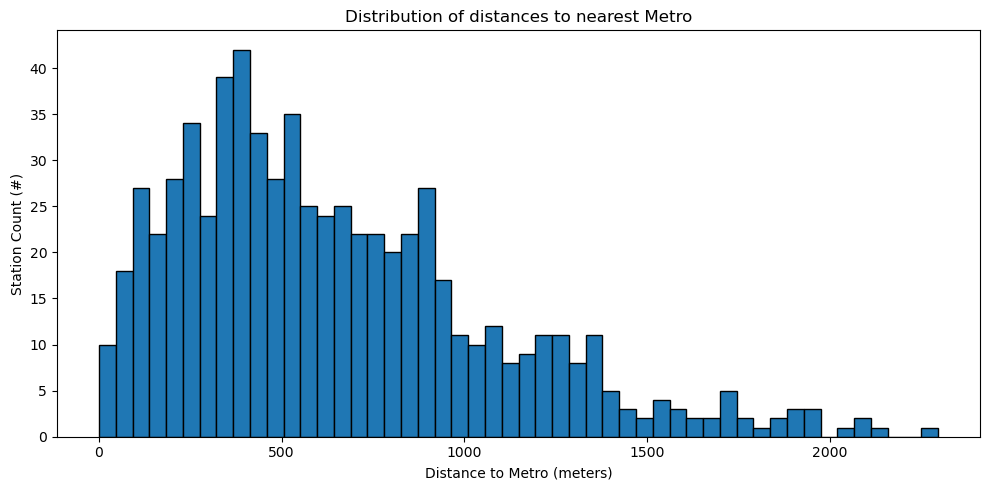


Min distance: 0 meters
Max distance: 2297 meters
Mean distance: 645 meters
Median distance: 549 meters


In [31]:
# Basic stats
print("Distance to Metro Statistics (decimal degrees):")
print(output_df['distance_to_metro'].describe())

# Convert to meters for readability
output_df['distance_to_metro_m'] = output_df['distance_to_metro'] * 111000

print("\nDistance to Metro Statistics (meters):")
print(output_df['distance_to_metro_m'].describe())

# Visualize distribution
fig, ax = plt.subplots(figsize=(10, 5))

# Histogram
ax.hist(output_df['distance_to_metro_m'], bins=50, edgecolor='black')
ax.set_xlabel('Distance to Metro (meters)')
ax.set_ylabel('Station Count (#)')
ax.set_title('Distribution of distances to nearest Metro')

plt.tight_layout()
plt.show()

# Check outliers
print(f"\nMin distance: {output_df['distance_to_metro_m'].min():.0f} meters")
print(f"Max distance: {output_df['distance_to_metro_m'].max():.0f} meters")
print(f"Mean distance: {output_df['distance_to_metro_m'].mean():.0f} meters")
print(f"Median distance: {output_df['distance_to_metro_m'].median():.0f} meters")

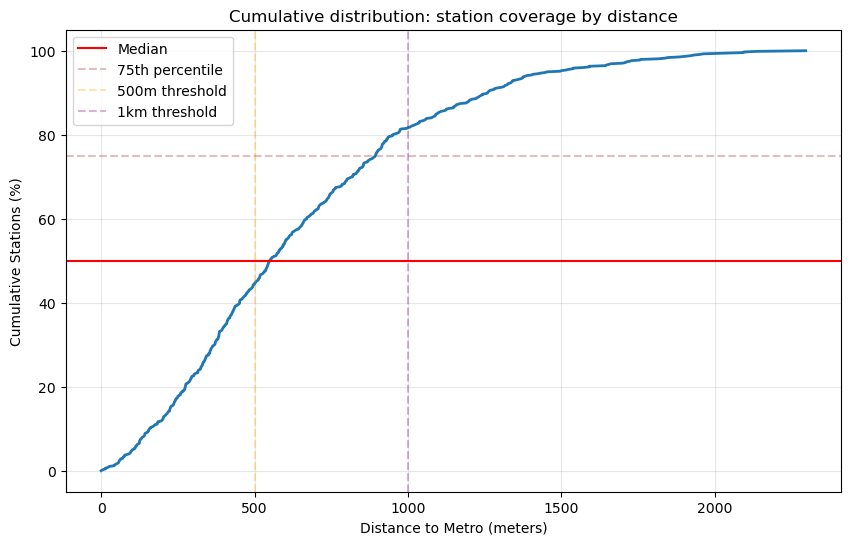

In [33]:
# Calculate cumulative %
sorted_distances = np.sort(output_df['distance_to_metro_m'])
cumulative = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances) * 100

plt.figure(figsize=(10, 6))
plt.plot(sorted_distances, cumulative, linewidth=2)
plt.axhline(y=50, color='r', linestyle='-', alpha=1, label='Median')
plt.axhline(y=75, color='brown', linestyle='--', alpha=0.3, label='75th percentile')
plt.axvline(x=500, color='orange', linestyle='--', alpha=0.3, label='500m threshold')
plt.axvline(x=1000, color='purple', linestyle='--', alpha=0.3, label='1km threshold')
plt.xlabel('Distance to Metro (meters)')
plt.ylabel('Cumulative Stations (%)')
plt.title('Cumulative distribution: station coverage by distance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- Nearly 50% of ECOBICI stations are within 600-700m of metro/subway, so a walkable distance
- Nearly 80% of ECOBICI stations fall within the 1km of metro/subway, making it relatively well for multimodality purposes
- About 20% of ECOBICI stations are beyond a 1km distance, meaning they are potential edge cases


In [ ]:
# Distance in meters to decimal degrees
output_df['distance_to_metro_m'] = output_df['distance_to_metro'] * 111000

In [ ]:
# Save to stations gbfs
output_df.to_parquet(REF_DIR / "stations_gbfs_with_metro_distance.parquet", index=False)